In [1]:
# ============================================================
# PERBANDINGAN CLASS WEIGHT - 3 BOBOT x 3 ARSITEKTUR (LENGKAP)
# NORMAL_WEIGHT = 1.0, 1.5, 2.0 untuk EfficientNet-B0, MobileNetV2,
# DenseNet121 dalam SATU notebook. Total 9 pelatihan (~2 jam GPU).
#
# Tiap kombinasi menghasilkan grafik lengkap:
#   - Kurva akurasi & loss (train vs val)
#   - Confusion matrix
#   - Metrik per kelas (precision/recall/F1)
# Di akhir: tabel + grafik perbandingan recall 'normal' & F1 antar-bobot.
#
# Split asli, regularisasi sedang (dropout 0.4, weight decay 5e-4).
# Tiap blok "# %%" = satu sel notebook.
# ============================================================

In [2]:
# %% ================= SEL 0: CEK PATH DATASET =================
import os
for nama_dataset in sorted(os.listdir('/kaggle/input')):
    print("Dataset:", nama_dataset)
    for isi in sorted(os.listdir('/kaggle/input/' + nama_dataset)):
        print("   -", isi)

Dataset: datasets
   - dilaaurafutri


In [3]:
# %% ================= SEL 1: PENGATURAN =================
DAFTAR_ARSITEKTUR = ["efficientnet_b0", "mobilenet_v2", "densenet121"]
DAFTAR_BOBOT = [1.0, 1.5, 2.0]
 
# GANTI sesuai hasil Sel 0:
DATA_DIR = "/kaggle/input/datasets/dilaaurafutri/skin-type-classification-4-types/dataset_skintype_vit_final_crop"
 
UKURAN_RESIZE = 256
UKURAN_CROP   = 224
BATCH_SIZE    = 32
DROPOUT       = 0.4
WEIGHT_DECAY  = 0.0005
LEARNING_RATE = 0.0001
MAX_EPOCH     = 30
PATIENCE      = 4
SEED          = 42
 
FIG_DIR = "/kaggle/working/figures"
os.makedirs(FIG_DIR, exist_ok=True)

In [4]:
# %% ================= SEL 2: IMPORT & PERSIAPAN =================
import random
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
 
sns.set_theme(style="whitegrid")
 
def kunci_seed(angka):
    random.seed(angka)
    np.random.seed(angka)
    torch.manual_seed(angka)
    torch.cuda.manual_seed_all(angka)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
 
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Device:", device)

Device: cuda


In [5]:
# %% ================= SEL 3: TRANSFORMASI GAMBAR =================
MEAN_IMAGENET = [0.485, 0.456, 0.406]
STD_IMAGENET  = [0.229, 0.224, 0.225]
 
transform_latih = transforms.Compose([
    transforms.Resize(UKURAN_RESIZE),
    transforms.RandomResizedCrop(UKURAN_CROP, scale=(0.65, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(MEAN_IMAGENET, STD_IMAGENET),
])
transform_uji = transforms.Compose([
    transforms.Resize(UKURAN_RESIZE),
    transforms.CenterCrop(UKURAN_CROP),
    transforms.ToTensor(),
    transforms.Normalize(MEAN_IMAGENET, STD_IMAGENET),
])

In [6]:
# %% ================= SEL 4: MEMUAT DATASET =================
data_latih    = datasets.ImageFolder(DATA_DIR + "/train", transform=transform_latih)
data_validasi = datasets.ImageFolder(DATA_DIR + "/valid", transform=transform_uji)
data_uji      = datasets.ImageFolder(DATA_DIR + "/test",  transform=transform_uji)
 
NAMA_KELAS = ["combination", "dry", "normal", "oily"]
if data_latih.classes != NAMA_KELAS:
    print("PERINGATAN: urutan kelas tidak sesuai:", data_latih.classes)
else:
    print("Urutan kelas benar:", data_latih.classes)
print("Train:", len(data_latih), "| Valid:", len(data_validasi), "| Test:", len(data_uji))
 
loader_latih    = DataLoader(data_latih, batch_size=BATCH_SIZE, shuffle=True)
loader_validasi = DataLoader(data_validasi, batch_size=BATCH_SIZE, shuffle=False)
loader_uji      = DataLoader(data_uji, batch_size=BATCH_SIZE, shuffle=False)

Urutan kelas benar: ['combination', 'dry', 'normal', 'oily']
Train: 1599 | Valid: 200 | Test: 200


In [7]:
# %% ================= SEL 5: FUNGSI BANGUN MODEL =================
def bangun_model(arch):
    if arch == "efficientnet_b0":
        model = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        jf = model.classifier[1].in_features
        model.classifier = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(jf, 4))
    elif arch == "mobilenet_v2":
        model = models.mobilenet_v2(
            weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        jf = model.classifier[1].in_features
        model.classifier = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(jf, 4))
    elif arch == "densenet121":
        model = models.densenet121(
            weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        jf = model.classifier.in_features
        model.classifier = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(jf, 4))
    return model.to(device)

In [8]:
# %% ================= SEL 6: FUNGSI LATIH + EVALUASI + GRAFIK =================
# Melatih SATU arsitektur dengan SATU bobot, menghasilkan 3 grafik
# (kurva, confusion matrix, metrik per kelas), lalu mengembalikan metrik.
def latih_dan_evaluasi(arch, bobot):
    tag = arch + "_w" + str(bobot)   # penanda unik utk nama file grafik
    print("")
    print("============================================================")
    print("TRAINING:", arch, "| NORMAL_WEIGHT =", bobot)
    print("============================================================")
 
    kunci_seed(SEED)
    model = bangun_model(arch)
    bobot_kelas = torch.tensor([1.0, 1.0, bobot, 1.0]).to(device)
    criterion = nn.CrossEntropyLoss(weight=bobot_kelas)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE,
                                  weight_decay=WEIGHT_DECAY)
 
    # riwayat untuk kurva
    r_epoch, r_loss_latih, r_acc_latih = [], [], []
    r_loss_val, r_acc_val = [], []
 
    f1_terbaik = 0.0
    hitung_tidak_membaik = 0
    path_checkpoint = "/kaggle/working/best_" + tag + ".pth"
 
    for epoch in range(1, MAX_EPOCH + 1):
        # fase latih
        model.train()
        total_loss_latih = 0.0
        benar_latih = 0
        for gambar, label in loader_latih:
            gambar = gambar.to(device)
            label = label.to(device)
            keluaran = model(gambar)
            loss = criterion(keluaran, label)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss_latih = total_loss_latih + loss.item() * gambar.size(0)
            benar_latih = benar_latih + (keluaran.argmax(1) == label).sum().item()
        loss_latih = total_loss_latih / len(data_latih)
        acc_latih = benar_latih / len(data_latih)
 
        # fase validasi
        model.eval()
        total_loss_val = 0.0
        prediksi_val, label_val = [], []
        with torch.no_grad():
            for gambar, label in loader_validasi:
                gambar = gambar.to(device)
                label = label.to(device)
                keluaran = model(gambar)
                loss = criterion(keluaran, label)
                total_loss_val = total_loss_val + loss.item() * gambar.size(0)
                for p in keluaran.argmax(1).cpu().numpy():
                    prediksi_val.append(p)
                for l in label.cpu().numpy():
                    label_val.append(l)
        loss_val = total_loss_val / len(data_validasi)
        acc_val = accuracy_score(label_val, prediksi_val)
        f1_val = f1_score(label_val, prediksi_val, average="macro")
        gap = (acc_latih - acc_val) * 100
 
        r_epoch.append(epoch)
        r_loss_latih.append(loss_latih); r_acc_latih.append(acc_latih)
        r_loss_val.append(loss_val); r_acc_val.append(acc_val)
 
        print("Epoch", epoch,
              "| acc latih", round(acc_latih * 100, 2),
              "| acc val", round(acc_val * 100, 2),
              "| F1 val", round(f1_val * 100, 2),
              "| gap", round(gap, 1))
 
        if f1_val > f1_terbaik:
            f1_terbaik = f1_val
            hitung_tidak_membaik = 0
            torch.save(model.state_dict(), path_checkpoint)
        else:
            hitung_tidak_membaik = hitung_tidak_membaik + 1
            if hitung_tidak_membaik >= PATIENCE:
                print("   >> early stopping di epoch", epoch)
                break
 
    # --- GRAFIK 1: kurva akurasi & loss ---
    acc_latih_persen = [a * 100 for a in r_acc_latih]
    acc_val_persen = [a * 100 for a in r_acc_val]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(r_epoch, acc_latih_persen, "o-", label="Train")
    axes[0].plot(r_epoch, acc_val_persen, "s-", label="Validation")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Akurasi (%)")
    axes[0].set_title("Kurva Akurasi - " + tag); axes[0].legend()
    axes[1].plot(r_epoch, r_loss_latih, "o-", label="Train")
    axes[1].plot(r_epoch, r_loss_val, "s-", label="Validation")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].set_title("Kurva Loss - " + tag); axes[1].legend()
    plt.savefig(FIG_DIR + "/kurva_" + tag + ".png", dpi=300, bbox_inches="tight")
    plt.show()
 
    # --- evaluasi test memakai checkpoint terbaik ---
    model.load_state_dict(torch.load(path_checkpoint))
    model.eval()
    prediksi_uji, label_uji = [], []
    with torch.no_grad():
        for gambar, label in loader_uji:
            gambar = gambar.to(device)
            keluaran = model(gambar)
            for p in keluaran.argmax(1).cpu().numpy():
                prediksi_uji.append(p)
            for l in label.numpy():
                label_uji.append(l)
 
    akurasi = accuracy_score(label_uji, prediksi_uji)
    presisi = precision_score(label_uji, prediksi_uji, average="macro")
    recall  = recall_score(label_uji, prediksi_uji, average="macro")
    f1      = f1_score(label_uji, prediksi_uji, average="macro")
    recall_per_kelas = recall_score(label_uji, prediksi_uji, average=None)
    recall_normal = recall_per_kelas[2]
 
    print("HASIL TEST", tag, ": Acc", round(akurasi*100,2),
          "| F1", round(f1*100,2), "| Recall normal", round(recall_normal*100,2))
    print(classification_report(label_uji, prediksi_uji,
                                target_names=NAMA_KELAS, digits=4))
 
    # --- GRAFIK 2: confusion matrix ---
    cm = confusion_matrix(label_uji, prediksi_uji)
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=NAMA_KELAS, yticklabels=NAMA_KELAS, cbar=False)
    ax.set_xlabel("Prediksi"); ax.set_ylabel("Aktual")
    ax.set_title("Confusion Matrix - " + tag)
    plt.savefig(FIG_DIR + "/confusion_" + tag + ".png", dpi=300, bbox_inches="tight")
    plt.show()
 
    # --- GRAFIK 3: metrik per kelas ---
    prec_k = precision_score(label_uji, prediksi_uji, average=None)
    rec_k  = recall_score(label_uji, prediksi_uji, average=None)
    f1_k   = f1_score(label_uji, prediksi_uji, average=None)
    posisi = np.arange(4); lebar = 0.25
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(posisi - lebar, prec_k * 100, lebar, label="Precision")
    ax.bar(posisi, rec_k * 100, lebar, label="Recall")
    ax.bar(posisi + lebar, f1_k * 100, lebar, label="F1-score")
    ax.set_xticks(posisi); ax.set_xticklabels(NAMA_KELAS)
    ax.set_ylabel("Skor (%)"); ax.set_ylim(0, 100)
    ax.set_title("Metrik per Kelas - " + tag); ax.legend()
    plt.savefig(FIG_DIR + "/per_kelas_" + tag + ".png", dpi=300, bbox_inches="tight")
    plt.show()
 
    return {"akurasi": akurasi, "presisi": presisi, "recall": recall,
            "f1": f1, "recall_normal": recall_normal}


TRAINING: efficientnet_b0 | NORMAL_WEIGHT = 1.0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 182MB/s]


Epoch 1 | acc latih 45.53 | acc val 56.0 | F1 val 54.37 | gap -10.5
Epoch 2 | acc latih 62.48 | acc val 63.5 | F1 val 62.8 | gap -1.0
Epoch 3 | acc latih 69.23 | acc val 66.0 | F1 val 64.94 | gap 3.2
Epoch 4 | acc latih 73.42 | acc val 67.0 | F1 val 66.11 | gap 6.4
Epoch 5 | acc latih 74.61 | acc val 68.0 | F1 val 67.33 | gap 6.6
Epoch 6 | acc latih 77.92 | acc val 67.0 | F1 val 66.07 | gap 10.9
Epoch 7 | acc latih 81.18 | acc val 70.0 | F1 val 69.36 | gap 11.2
Epoch 8 | acc latih 82.36 | acc val 67.5 | F1 val 66.81 | gap 14.9
Epoch 9 | acc latih 85.43 | acc val 73.0 | F1 val 72.53 | gap 12.4
Epoch 10 | acc latih 86.3 | acc val 69.0 | F1 val 68.51 | gap 17.3
Epoch 11 | acc latih 88.06 | acc val 71.5 | F1 val 70.93 | gap 16.6
Epoch 12 | acc latih 90.62 | acc val 74.0 | F1 val 73.55 | gap 16.6
Epoch 13 | acc latih 91.49 | acc val 69.5 | F1 val 68.1 | gap 22.0
Epoch 14 | acc latih 92.75 | acc val 73.0 | F1 val 72.46 | gap 19.7
Epoch 15 | acc latih 93.62 | acc val 70.5 | F1 val 69.92 | gap

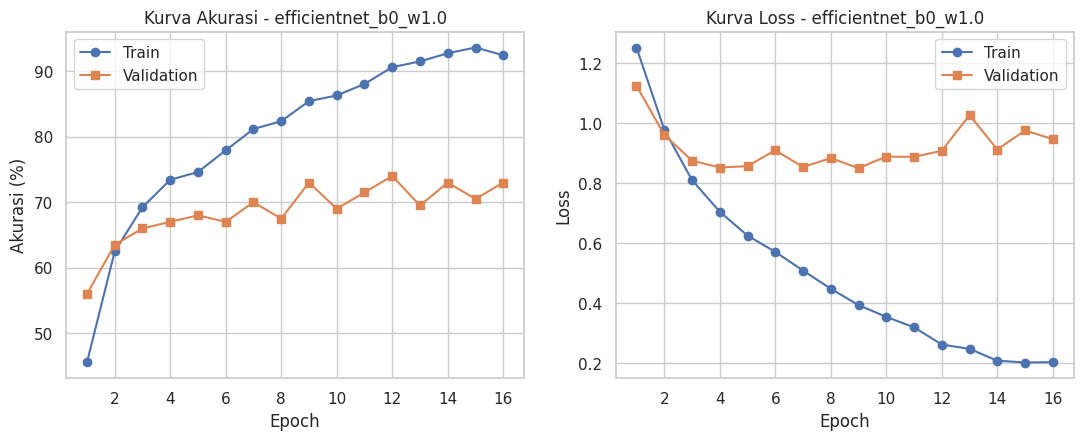

HASIL TEST efficientnet_b0_w1.0 : Acc 76.0 | F1 75.35 | Recall normal 52.0
              precision    recall  f1-score   support

 combination     0.7551    0.7400    0.7475        50
         dry     0.8431    0.8600    0.8515        50
      normal     0.8387    0.5200    0.6420        50
        oily     0.6667    0.9200    0.7731        50

    accuracy                         0.7600       200
   macro avg     0.7759    0.7600    0.7535       200
weighted avg     0.7759    0.7600    0.7535       200



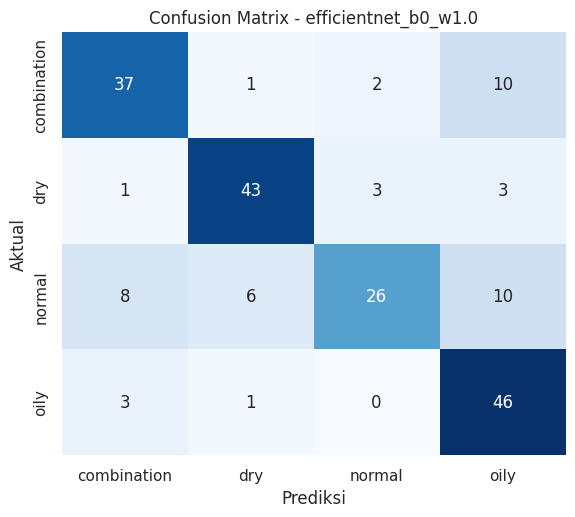

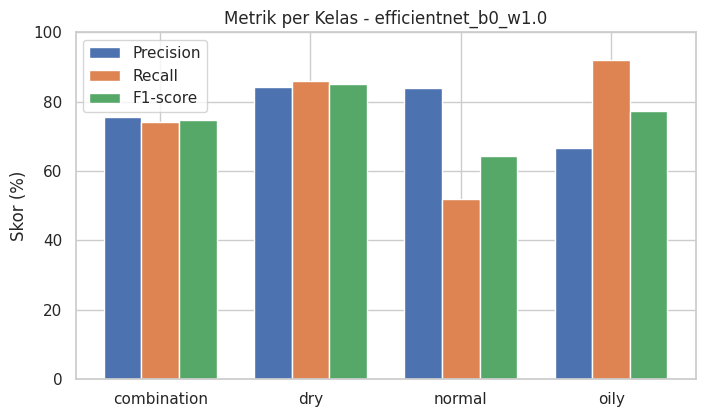


TRAINING: mobilenet_v2 | NORMAL_WEIGHT = 1.0
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 192MB/s]


Epoch 1 | acc latih 50.53 | acc val 60.5 | F1 val 59.42 | gap -10.0
Epoch 2 | acc latih 66.92 | acc val 65.0 | F1 val 64.63 | gap 1.9
Epoch 3 | acc latih 72.42 | acc val 66.5 | F1 val 66.2 | gap 5.9
Epoch 4 | acc latih 75.23 | acc val 70.5 | F1 val 70.31 | gap 4.7
Epoch 5 | acc latih 77.92 | acc val 69.0 | F1 val 68.47 | gap 8.9
Epoch 6 | acc latih 80.18 | acc val 67.5 | F1 val 66.67 | gap 12.7
Epoch 7 | acc latih 82.55 | acc val 67.0 | F1 val 66.66 | gap 15.6
Epoch 8 | acc latih 84.55 | acc val 62.5 | F1 val 62.29 | gap 22.1
   >> early stopping di epoch 8


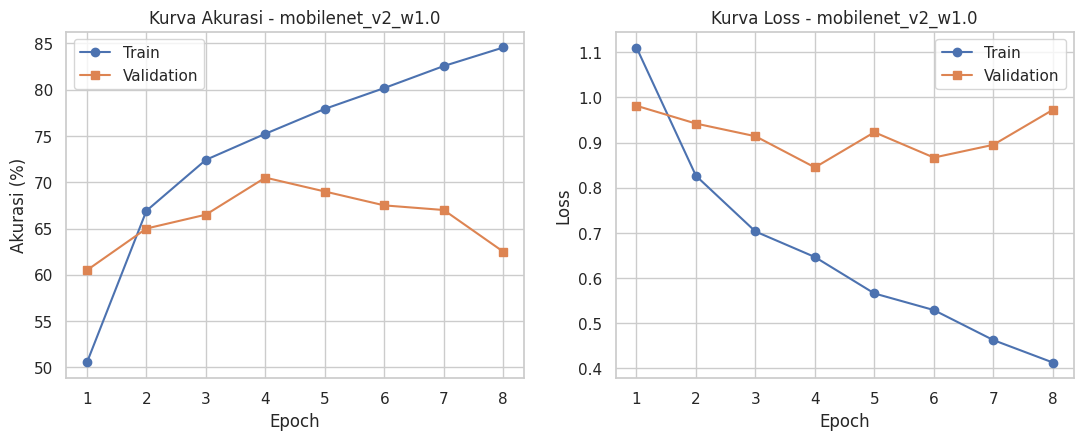

HASIL TEST mobilenet_v2_w1.0 : Acc 77.0 | F1 76.33 | Recall normal 52.0
              precision    recall  f1-score   support

 combination     0.7500    0.7800    0.7647        50
         dry     0.8302    0.8800    0.8544        50
      normal     0.8966    0.5200    0.6582        50
        oily     0.6818    0.9000    0.7759        50

    accuracy                         0.7700       200
   macro avg     0.7896    0.7700    0.7633       200
weighted avg     0.7896    0.7700    0.7633       200



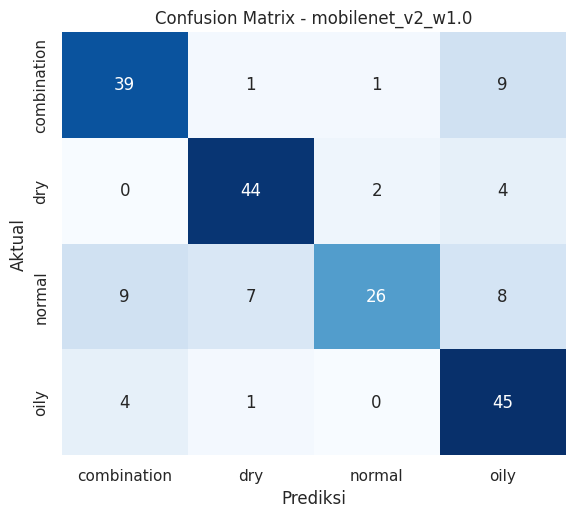

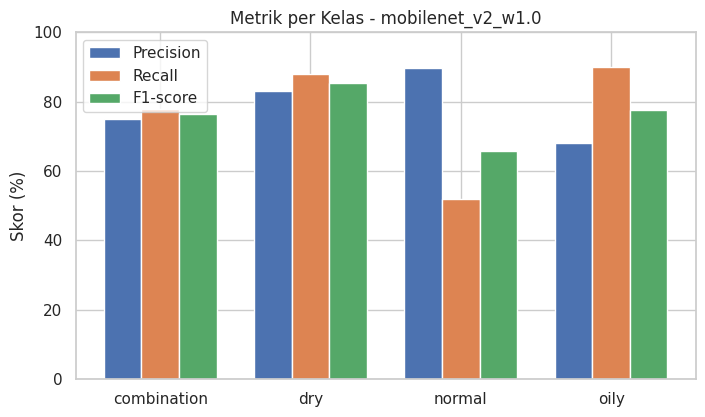


TRAINING: densenet121 | NORMAL_WEIGHT = 1.0
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 196MB/s]


Epoch 1 | acc latih 47.59 | acc val 55.0 | F1 val 54.22 | gap -7.4
Epoch 2 | acc latih 66.42 | acc val 63.5 | F1 val 62.56 | gap 2.9
Epoch 3 | acc latih 73.55 | acc val 68.0 | F1 val 67.02 | gap 5.5
Epoch 4 | acc latih 77.05 | acc val 68.5 | F1 val 67.78 | gap 8.5
Epoch 5 | acc latih 80.86 | acc val 61.5 | F1 val 59.9 | gap 19.4
Epoch 6 | acc latih 82.86 | acc val 68.0 | F1 val 66.5 | gap 14.9
Epoch 7 | acc latih 84.62 | acc val 68.5 | F1 val 67.35 | gap 16.1
Epoch 8 | acc latih 86.74 | acc val 68.0 | F1 val 67.16 | gap 18.7
   >> early stopping di epoch 8


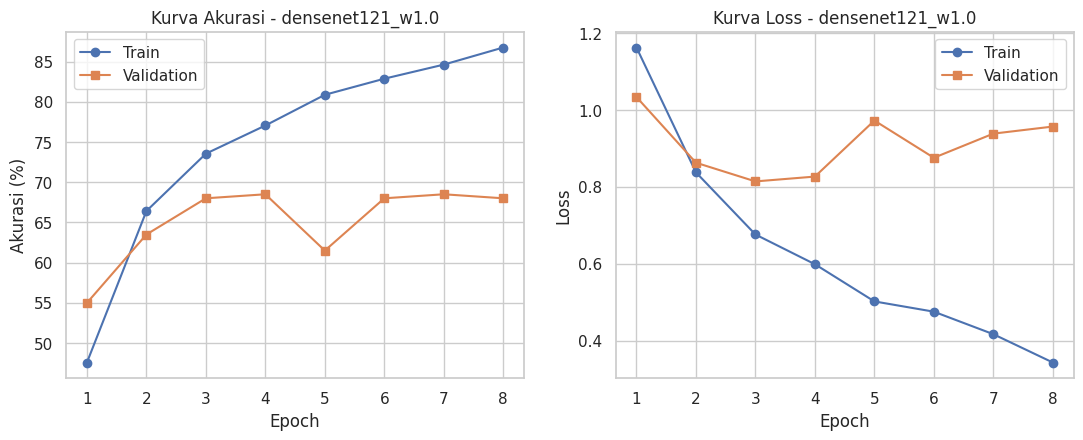

HASIL TEST densenet121_w1.0 : Acc 78.5 | F1 76.79 | Recall normal 42.0
              precision    recall  f1-score   support

 combination     0.8269    0.8600    0.8431        50
         dry     0.7460    0.9400    0.8319        50
      normal     0.9130    0.4200    0.5753        50
        oily     0.7419    0.9200    0.8214        50

    accuracy                         0.7850       200
   macro avg     0.8070    0.7850    0.7679       200
weighted avg     0.8070    0.7850    0.7679       200



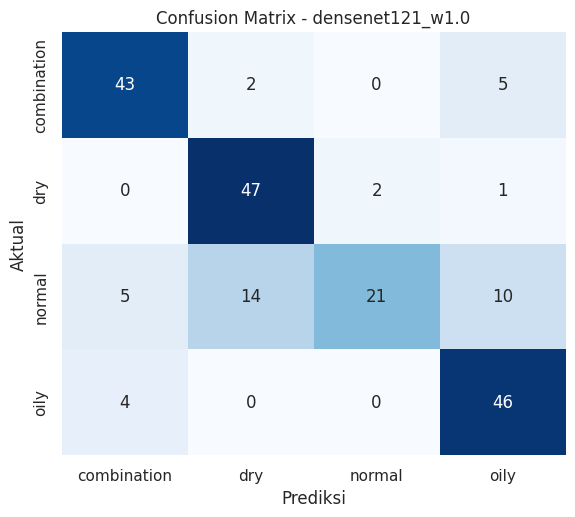

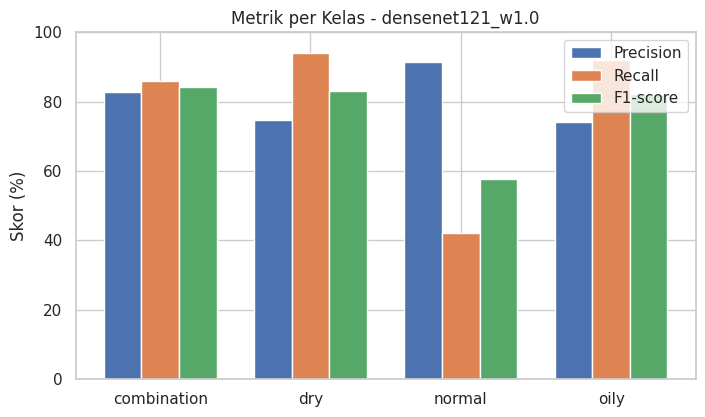


TRAINING: efficientnet_b0 | NORMAL_WEIGHT = 1.5
Epoch 1 | acc latih 44.84 | acc val 57.0 | F1 val 55.71 | gap -12.2
Epoch 2 | acc latih 60.85 | acc val 65.0 | F1 val 64.74 | gap -4.1
Epoch 3 | acc latih 67.73 | acc val 66.5 | F1 val 65.9 | gap 1.2
Epoch 4 | acc latih 71.79 | acc val 67.0 | F1 val 66.68 | gap 4.8
Epoch 5 | acc latih 74.92 | acc val 69.5 | F1 val 69.25 | gap 5.4
Epoch 6 | acc latih 77.55 | acc val 67.5 | F1 val 66.88 | gap 10.0
Epoch 7 | acc latih 81.61 | acc val 71.5 | F1 val 71.06 | gap 10.1
Epoch 8 | acc latih 82.8 | acc val 70.5 | F1 val 70.05 | gap 12.3
Epoch 9 | acc latih 85.43 | acc val 73.5 | F1 val 72.96 | gap 11.9
Epoch 10 | acc latih 86.43 | acc val 69.0 | F1 val 68.56 | gap 17.4
Epoch 11 | acc latih 88.12 | acc val 73.5 | F1 val 73.1 | gap 14.6
Epoch 12 | acc latih 90.62 | acc val 73.5 | F1 val 72.95 | gap 17.1
Epoch 13 | acc latih 90.81 | acc val 68.0 | F1 val 66.78 | gap 22.8
Epoch 14 | acc latih 92.75 | acc val 74.0 | F1 val 73.45 | gap 18.7
Epoch 15 | ac

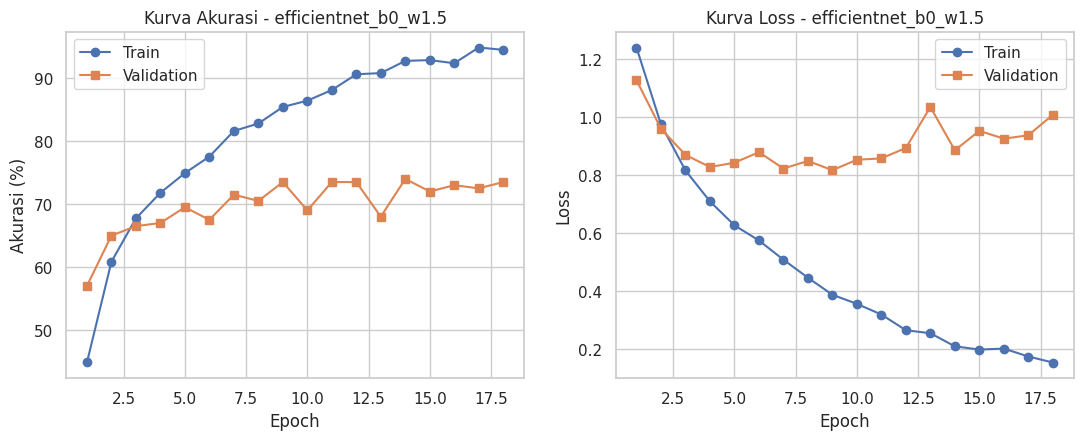

HASIL TEST efficientnet_b0_w1.5 : Acc 76.0 | F1 75.83 | Recall normal 60.0
              precision    recall  f1-score   support

 combination     0.7955    0.7000    0.7447        50
         dry     0.9070    0.7800    0.8387        50
      normal     0.7895    0.6000    0.6818        50
        oily     0.6400    0.9600    0.7680        50

    accuracy                         0.7600       200
   macro avg     0.7830    0.7600    0.7583       200
weighted avg     0.7830    0.7600    0.7583       200



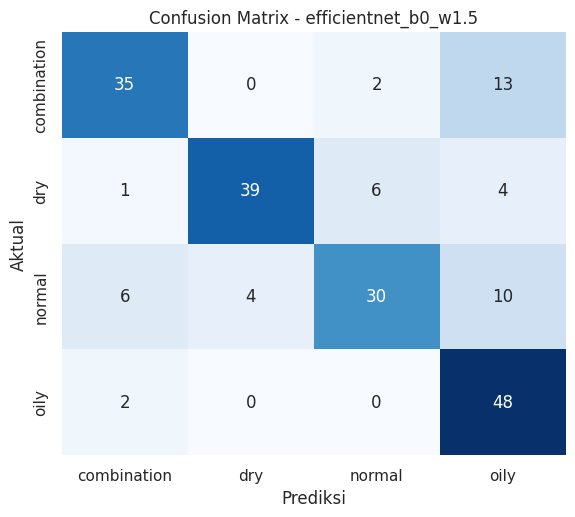

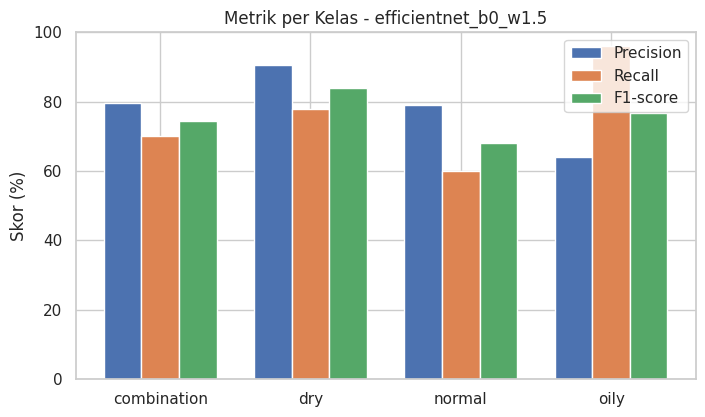


TRAINING: mobilenet_v2 | NORMAL_WEIGHT = 1.5
Epoch 1 | acc latih 48.84 | acc val 63.5 | F1 val 62.83 | gap -14.7
Epoch 2 | acc latih 65.23 | acc val 64.0 | F1 val 63.91 | gap 1.2
Epoch 3 | acc latih 72.11 | acc val 66.0 | F1 val 65.91 | gap 6.1
Epoch 4 | acc latih 74.42 | acc val 70.5 | F1 val 70.35 | gap 3.9
Epoch 5 | acc latih 77.86 | acc val 64.5 | F1 val 64.14 | gap 13.4
Epoch 6 | acc latih 79.42 | acc val 64.5 | F1 val 64.3 | gap 14.9
Epoch 7 | acc latih 82.55 | acc val 66.5 | F1 val 66.39 | gap 16.1
Epoch 8 | acc latih 84.24 | acc val 63.5 | F1 val 63.41 | gap 20.7
   >> early stopping di epoch 8


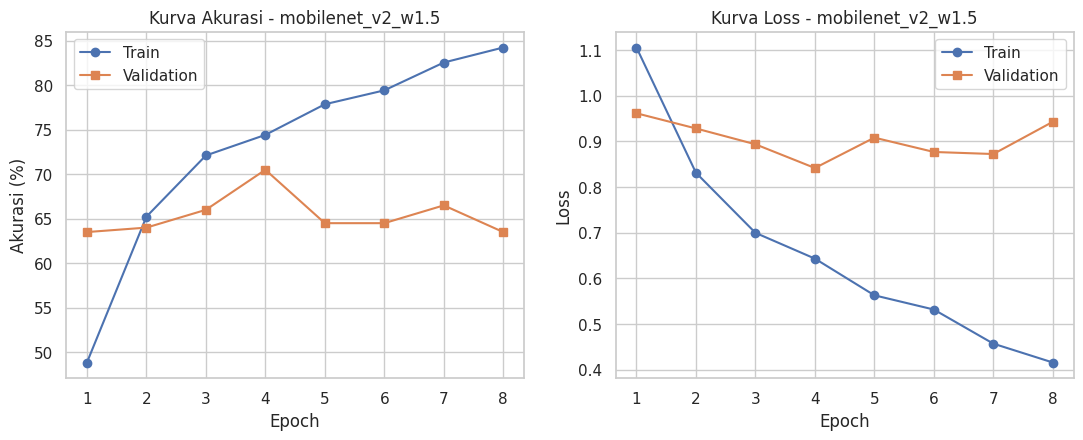

HASIL TEST mobilenet_v2_w1.5 : Acc 76.0 | F1 75.78 | Recall normal 60.0
              precision    recall  f1-score   support

 combination     0.7170    0.7600    0.7379        50
         dry     0.8542    0.8200    0.8367        50
      normal     0.7895    0.6000    0.6818        50
        oily     0.7049    0.8600    0.7748        50

    accuracy                         0.7600       200
   macro avg     0.7664    0.7600    0.7578       200
weighted avg     0.7664    0.7600    0.7578       200



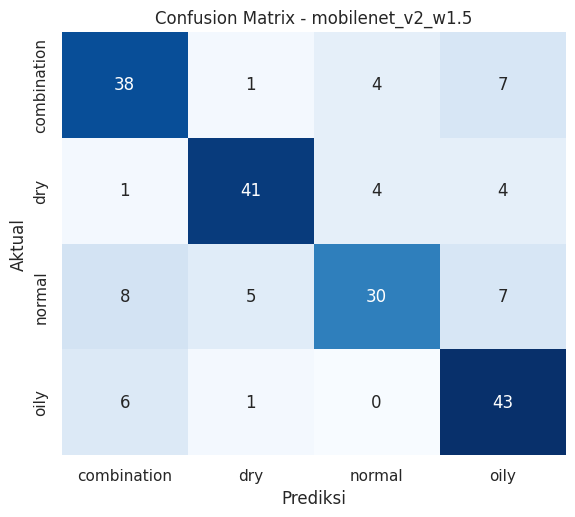

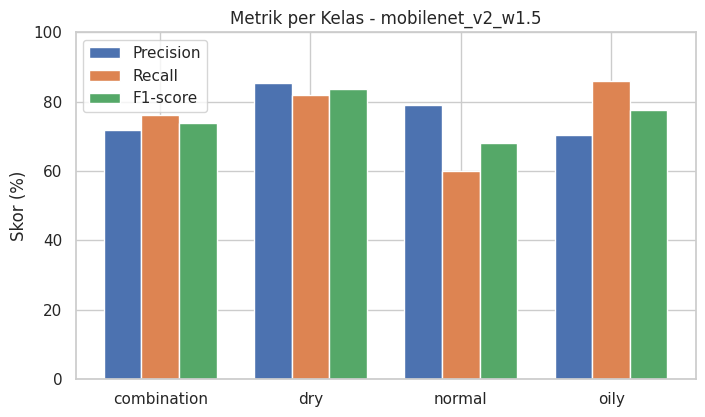


TRAINING: densenet121 | NORMAL_WEIGHT = 1.5
Epoch 1 | acc latih 46.65 | acc val 59.0 | F1 val 58.36 | gap -12.3
Epoch 2 | acc latih 65.42 | acc val 66.0 | F1 val 65.49 | gap -0.6
Epoch 3 | acc latih 73.11 | acc val 70.0 | F1 val 69.56 | gap 3.1
Epoch 4 | acc latih 77.55 | acc val 67.0 | F1 val 66.75 | gap 10.5
Epoch 5 | acc latih 80.49 | acc val 64.0 | F1 val 62.73 | gap 16.5
Epoch 6 | acc latih 81.68 | acc val 67.5 | F1 val 66.07 | gap 14.2
Epoch 7 | acc latih 83.74 | acc val 67.5 | F1 val 66.51 | gap 16.2
   >> early stopping di epoch 7


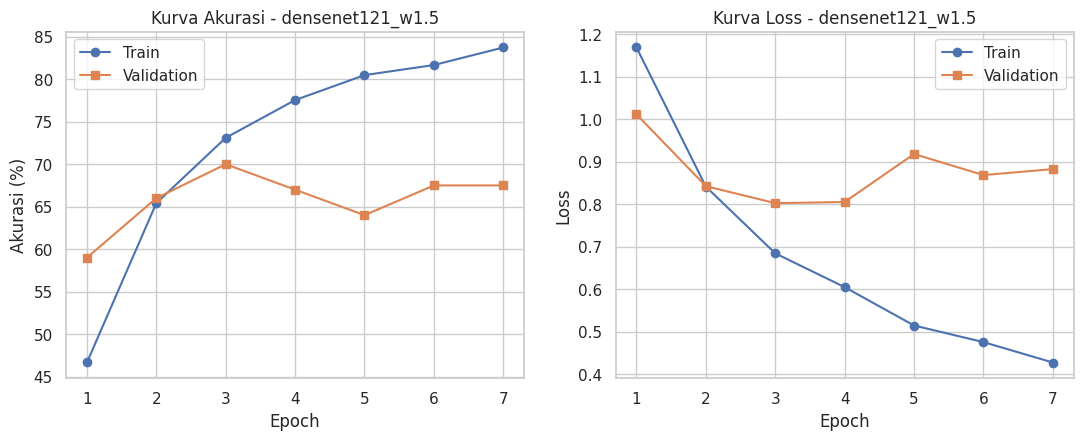

HASIL TEST densenet121_w1.5 : Acc 79.0 | F1 78.45 | Recall normal 58.0
              precision    recall  f1-score   support

 combination     0.8043    0.7400    0.7708        50
         dry     0.7833    0.9400    0.8545        50
      normal     0.9355    0.5800    0.7160        50
        oily     0.7143    0.9000    0.7965        50

    accuracy                         0.7900       200
   macro avg     0.8094    0.7900    0.7845       200
weighted avg     0.8094    0.7900    0.7845       200



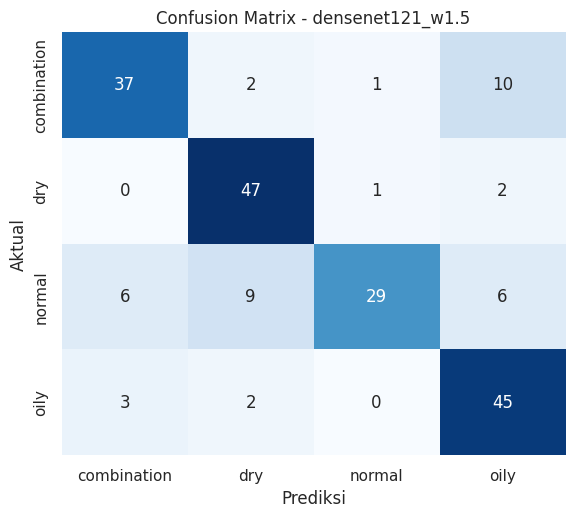

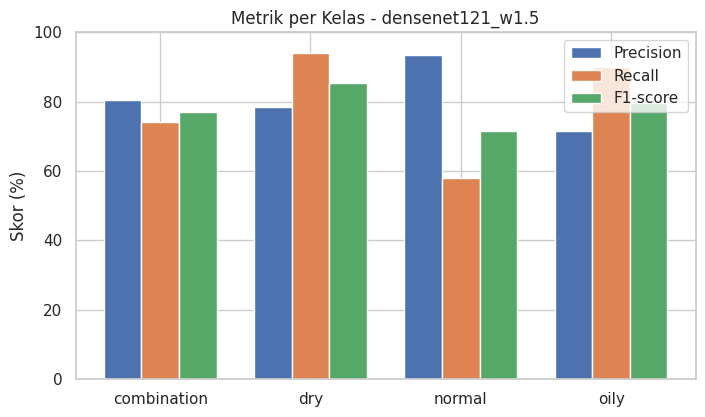


TRAINING: efficientnet_b0 | NORMAL_WEIGHT = 2.0
Epoch 1 | acc latih 42.71 | acc val 56.0 | F1 val 54.92 | gap -13.3
Epoch 2 | acc latih 59.04 | acc val 64.0 | F1 val 63.83 | gap -5.0
Epoch 3 | acc latih 66.6 | acc val 65.5 | F1 val 64.92 | gap 1.1
Epoch 4 | acc latih 70.48 | acc val 66.5 | F1 val 66.26 | gap 4.0
Epoch 5 | acc latih 74.05 | acc val 68.5 | F1 val 68.24 | gap 5.5
Epoch 6 | acc latih 76.36 | acc val 67.5 | F1 val 66.9 | gap 8.9
Epoch 7 | acc latih 80.43 | acc val 71.5 | F1 val 71.07 | gap 8.9
Epoch 8 | acc latih 82.49 | acc val 71.0 | F1 val 70.6 | gap 11.5
Epoch 9 | acc latih 84.8 | acc val 73.5 | F1 val 73.0 | gap 11.3
Epoch 10 | acc latih 85.24 | acc val 71.0 | F1 val 70.73 | gap 14.2
Epoch 11 | acc latih 87.62 | acc val 73.0 | F1 val 72.8 | gap 14.6
Epoch 12 | acc latih 89.74 | acc val 73.0 | F1 val 72.51 | gap 16.7
Epoch 13 | acc latih 89.74 | acc val 69.0 | F1 val 68.04 | gap 20.7
   >> early stopping di epoch 13


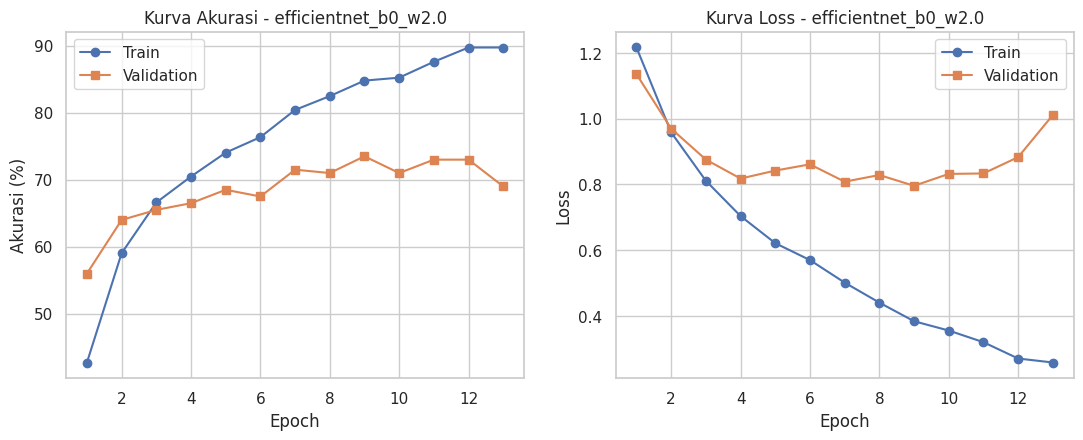

HASIL TEST efficientnet_b0_w2.0 : Acc 75.0 | F1 74.76 | Recall normal 60.0
              precision    recall  f1-score   support

 combination     0.7391    0.6800    0.7083        50
         dry     0.8864    0.7800    0.8298        50
      normal     0.7895    0.6000    0.6818        50
        oily     0.6528    0.9400    0.7705        50

    accuracy                         0.7500       200
   macro avg     0.7669    0.7500    0.7476       200
weighted avg     0.7669    0.7500    0.7476       200



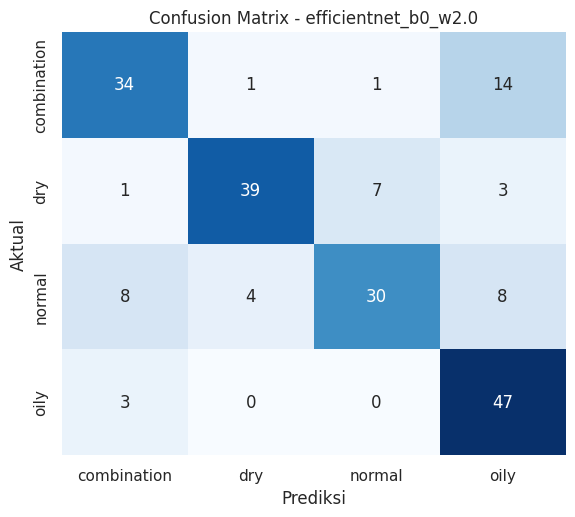

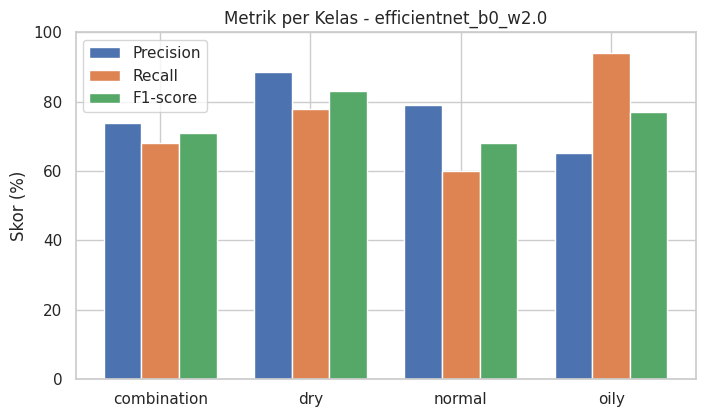


TRAINING: mobilenet_v2 | NORMAL_WEIGHT = 2.0
Epoch 1 | acc latih 47.97 | acc val 64.0 | F1 val 63.69 | gap -16.0
Epoch 2 | acc latih 64.73 | acc val 65.0 | F1 val 64.89 | gap -0.3
Epoch 3 | acc latih 70.61 | acc val 66.0 | F1 val 65.89 | gap 4.6
Epoch 4 | acc latih 72.61 | acc val 69.0 | F1 val 68.91 | gap 3.6
Epoch 5 | acc latih 76.42 | acc val 65.5 | F1 val 64.97 | gap 10.9
Epoch 6 | acc latih 78.55 | acc val 64.5 | F1 val 64.34 | gap 14.0
Epoch 7 | acc latih 81.93 | acc val 66.0 | F1 val 65.78 | gap 15.9
Epoch 8 | acc latih 83.43 | acc val 65.0 | F1 val 64.9 | gap 18.4
   >> early stopping di epoch 8


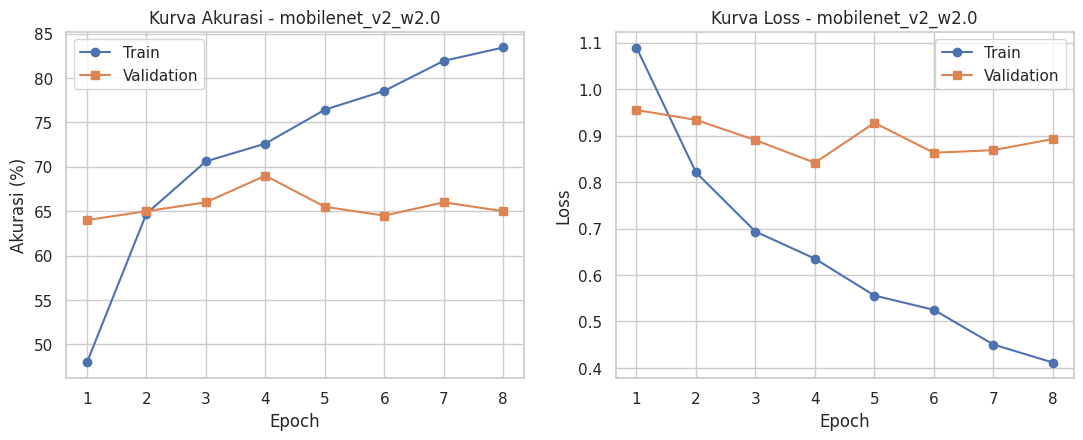

HASIL TEST mobilenet_v2_w2.0 : Acc 77.5 | F1 77.27 | Recall normal 62.0
              precision    recall  f1-score   support

 combination     0.7647    0.7800    0.7723        50
         dry     0.8542    0.8200    0.8367        50
      normal     0.7750    0.6200    0.6889        50
        oily     0.7213    0.8800    0.7928        50

    accuracy                         0.7750       200
   macro avg     0.7788    0.7750    0.7727       200
weighted avg     0.7788    0.7750    0.7727       200



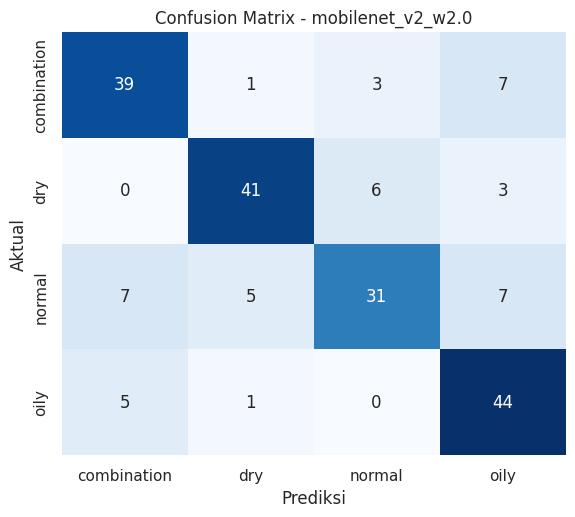

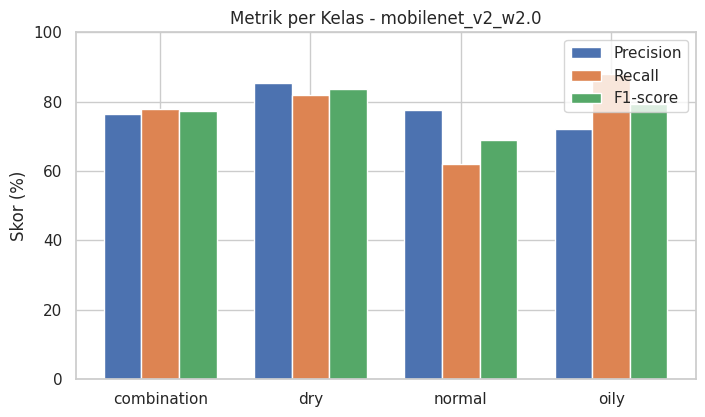


TRAINING: densenet121 | NORMAL_WEIGHT = 2.0
Epoch 1 | acc latih 46.09 | acc val 60.0 | F1 val 59.31 | gap -13.9
Epoch 2 | acc latih 62.48 | acc val 65.0 | F1 val 64.55 | gap -2.5
Epoch 3 | acc latih 70.98 | acc val 69.5 | F1 val 69.19 | gap 1.5
Epoch 4 | acc latih 75.36 | acc val 66.5 | F1 val 66.01 | gap 8.9
Epoch 5 | acc latih 79.8 | acc val 67.5 | F1 val 66.68 | gap 12.3
Epoch 6 | acc latih 81.86 | acc val 68.0 | F1 val 67.04 | gap 13.9
Epoch 7 | acc latih 82.99 | acc val 72.0 | F1 val 71.42 | gap 11.0
Epoch 8 | acc latih 87.18 | acc val 70.0 | F1 val 69.65 | gap 17.2
Epoch 9 | acc latih 87.87 | acc val 75.0 | F1 val 74.73 | gap 12.9
Epoch 10 | acc latih 89.31 | acc val 69.5 | F1 val 69.03 | gap 19.8
Epoch 11 | acc latih 91.37 | acc val 69.0 | F1 val 68.82 | gap 22.4
Epoch 12 | acc latih 92.18 | acc val 67.5 | F1 val 67.25 | gap 24.7
Epoch 13 | acc latih 93.5 | acc val 67.0 | F1 val 65.95 | gap 26.5
   >> early stopping di epoch 13


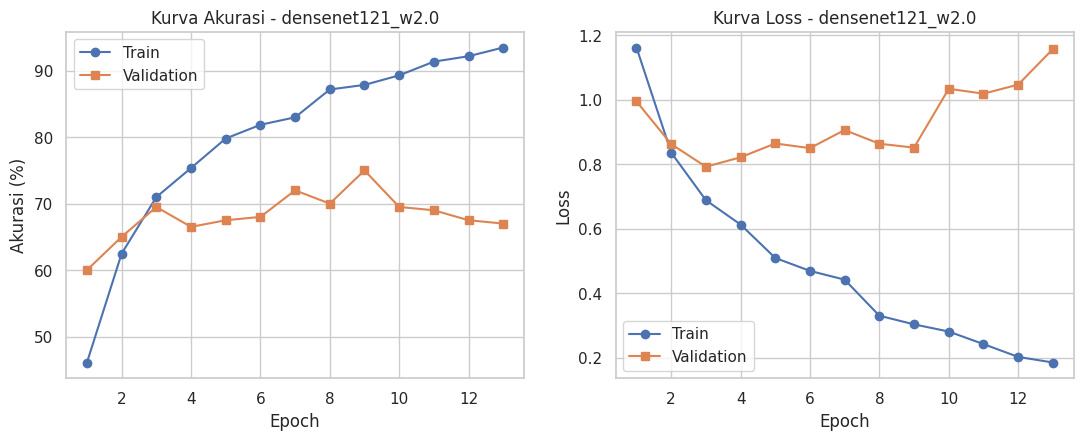

HASIL TEST densenet121_w2.0 : Acc 77.0 | F1 76.6 | Recall normal 58.0
              precision    recall  f1-score   support

 combination     0.8636    0.7600    0.8085        50
         dry     0.7455    0.8200    0.7810        50
      normal     0.6905    0.5800    0.6304        50
        oily     0.7797    0.9200    0.8440        50

    accuracy                         0.7700       200
   macro avg     0.7698    0.7700    0.7660       200
weighted avg     0.7698    0.7700    0.7660       200



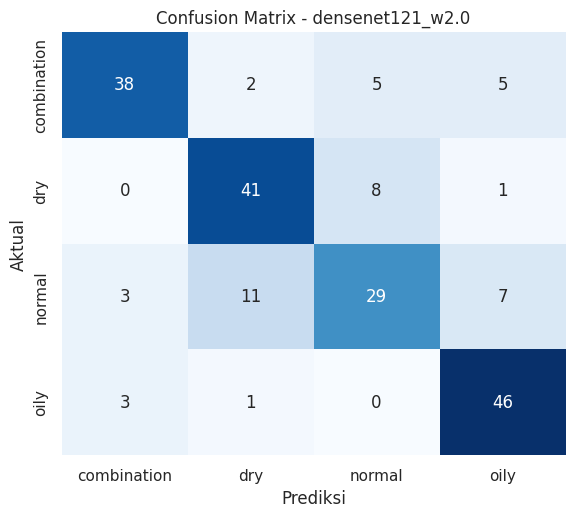

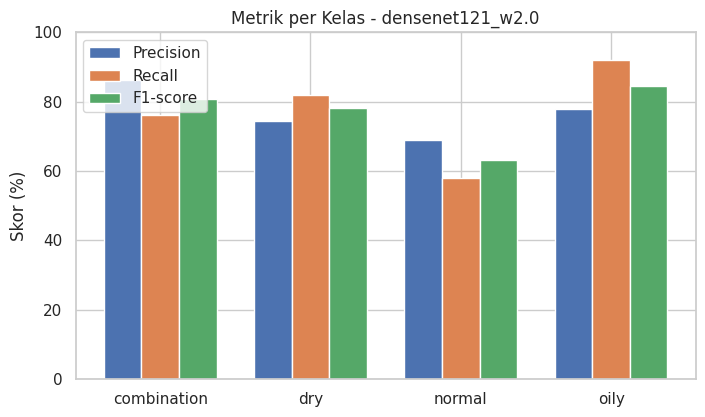


Semua hasil tersimpan.


In [9]:
# %% ================= SEL 7: JALANKAN SEMUA KOMBINASI (9 TRAINING) =================
hasil = {}
for bobot in DAFTAR_BOBOT:
    hasil[bobot] = {}
    for arch in DAFTAR_ARSITEKTUR:
        hasil[bobot][arch] = latih_dan_evaluasi(arch, bobot)
 
hasil_json = {}
for bobot in DAFTAR_BOBOT:
    hasil_json[str(bobot)] = {}
    for arch in DAFTAR_ARSITEKTUR:
        hasil_json[str(bobot)][arch] = hasil[bobot][arch]
with open("/kaggle/working/hasil_perbandingan_bobot.json", "w") as f:
    json.dump(hasil_json, f, indent=2)
print("\nSemua hasil tersimpan.")

In [10]:
# %% ================= SEL 8: TABEL PERBANDINGAN =================
print("PERBANDINGAN RECALL KELAS 'NORMAL' (%)")
print("Arsitektur".ljust(20), end="")
for bobot in DAFTAR_BOBOT:
    print(("w=" + str(bobot)).ljust(10), end="")
print("")
for arch in DAFTAR_ARSITEKTUR:
    print(arch.ljust(20), end="")
    for bobot in DAFTAR_BOBOT:
        print(str(round(hasil[bobot][arch]["recall_normal"]*100, 2)).ljust(10), end="")
    print("")
 
print("")
print("PERBANDINGAN F1 MACRO (%)")
print("Arsitektur".ljust(20), end="")
for bobot in DAFTAR_BOBOT:
    print(("w=" + str(bobot)).ljust(10), end="")
print("")
for arch in DAFTAR_ARSITEKTUR:
    print(arch.ljust(20), end="")
    for bobot in DAFTAR_BOBOT:
        print(str(round(hasil[bobot][arch]["f1"]*100, 2)).ljust(10), end="")
    print("")

PERBANDINGAN RECALL KELAS 'NORMAL' (%)
Arsitektur          w=1.0     w=1.5     w=2.0     
efficientnet_b0     52.0      60.0      60.0      
mobilenet_v2        52.0      60.0      62.0      
densenet121         42.0      58.0      58.0      

PERBANDINGAN F1 MACRO (%)
Arsitektur          w=1.0     w=1.5     w=2.0     
efficientnet_b0     75.35     75.83     74.76     
mobilenet_v2        76.33     75.78     77.27     
densenet121         76.79     78.45     76.6      


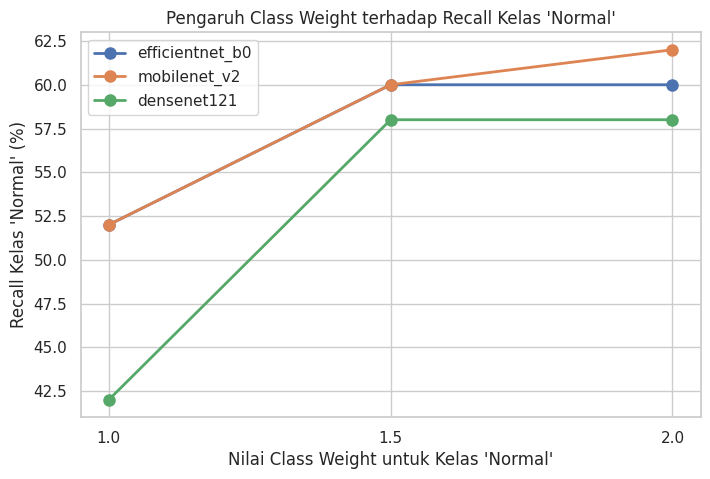

In [11]:
# %% ================= SEL 9 [GRAFIK]: RECALL 'NORMAL' vs BOBOT =================
fig, ax = plt.subplots(figsize=(8, 5))
for arch in DAFTAR_ARSITEKTUR:
    nilai = [hasil[b][arch]["recall_normal"] * 100 for b in DAFTAR_BOBOT]
    ax.plot(DAFTAR_BOBOT, nilai, "o-", label=arch, linewidth=2, markersize=8)
ax.set_xlabel("Nilai Class Weight untuk Kelas 'Normal'")
ax.set_ylabel("Recall Kelas 'Normal' (%)")
ax.set_title("Pengaruh Class Weight terhadap Recall Kelas 'Normal'")
ax.set_xticks(DAFTAR_BOBOT); ax.legend()
plt.savefig(FIG_DIR + "/perbandingan_recall_normal_vs_bobot.png",
            dpi=300, bbox_inches="tight")
plt.show()

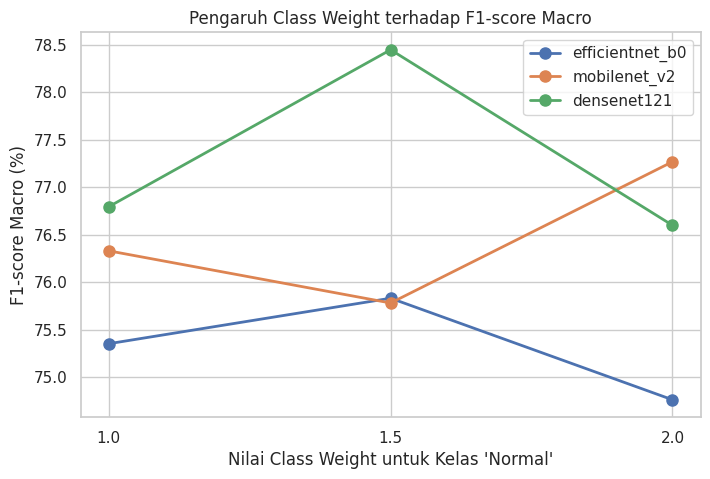


Selesai. Semua grafik (27 grafik kombinasi + 2 perbandingan) di /kaggle/working/figures
Jangan lupa Save & Commit di Kaggle.


In [12]:
# %% ================= SEL 10 [GRAFIK]: F1 MACRO vs BOBOT =================
fig, ax = plt.subplots(figsize=(8, 5))
for arch in DAFTAR_ARSITEKTUR:
    nilai = [hasil[b][arch]["f1"] * 100 for b in DAFTAR_BOBOT]
    ax.plot(DAFTAR_BOBOT, nilai, "o-", label=arch, linewidth=2, markersize=8)
ax.set_xlabel("Nilai Class Weight untuk Kelas 'Normal'")
ax.set_ylabel("F1-score Macro (%)")
ax.set_title("Pengaruh Class Weight terhadap F1-score Macro")
ax.set_xticks(DAFTAR_BOBOT); ax.legend()
plt.savefig(FIG_DIR + "/perbandingan_f1_vs_bobot.png",
            dpi=300, bbox_inches="tight")
plt.show()
 
print("\nSelesai. Semua grafik (27 grafik kombinasi + 2 perbandingan) di", FIG_DIR)
print("Jangan lupa Save & Commit di Kaggle.")

PENENTUAN KOMBINASI TERBAIK (berdasarkan F1 macro)

Peringkat  Arsitektur         Bobot    Acc      F1       Recall Normal
1          densenet121        1.5      79.0     78.45    58.0
2          mobilenet_v2       2.0      77.5     77.27    62.0
3          densenet121        1.0      78.5     76.79    42.0
4          densenet121        2.0      77.0     76.6     58.0
5          mobilenet_v2       1.0      77.0     76.33    52.0
6          efficientnet_b0    1.5      76.0     75.83    60.0
7          mobilenet_v2       1.5      76.0     75.78    60.0
8          efficientnet_b0    1.0      76.0     75.35    52.0
9          efficientnet_b0    2.0      75.0     74.76    60.0

KOMBINASI TERBAIK:
  Arsitektur   : densenet121
  Class Weight : 1.5
  Accuracy     : 79.0 %
  F1 macro     : 78.45 %
  Recall Normal: 58.0 %

Checkpoint model terbaik tersimpan di:
  /kaggle/working/best_densenet121_w1.5.pth
Gunakan file .pth ini untuk konversi ke ONNX (model final).


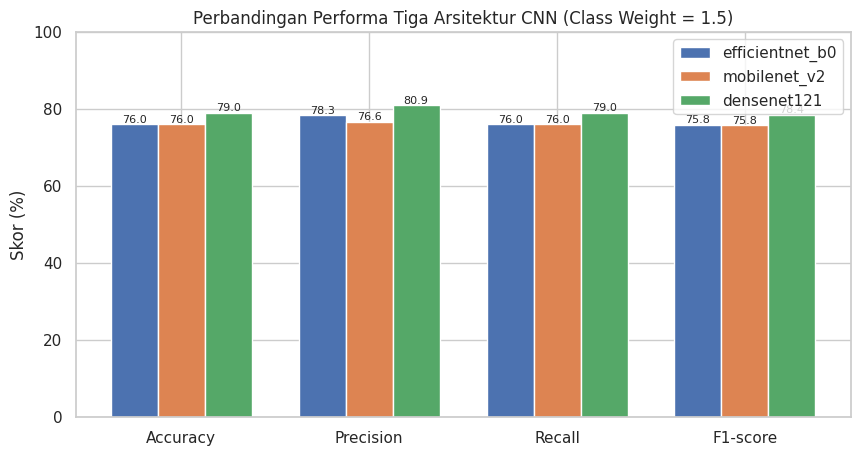


Perbandingan 3 arsitektur pada Class Weight = 1.5
Arsitektur         Acc      Prec     Rec      F1
efficientnet_b0    76.0     78.3     76.0     75.83
mobilenet_v2       76.0     76.64    76.0     75.78
densenet121        79.0     80.94    79.0     78.45

Arsitektur terbaik pada bobot 1.5 : densenet121


In [13]:
# %% ================= SEL 11: PEMILIHAN KOMBINASI TERBAIK =================
# Mencari kombinasi (arsitektur + bobot) dengan F1 macro tertinggi,
# sekaligus melaporkan recall 'normal'-nya. F1 macro dipakai sebagai
# kriteria utama karena mempertimbangkan keempat kelas secara setara.
 
print("=" * 60)
print("PENENTUAN KOMBINASI TERBAIK (berdasarkan F1 macro)")
print("=" * 60)
 
# Kumpulkan semua kombinasi ke satu daftar agar mudah diurutkan.
semua_kombinasi = []
for bobot in DAFTAR_BOBOT:
    for arch in DAFTAR_ARSITEKTUR:
        m = hasil[bobot][arch]
        semua_kombinasi.append({
            "arch": arch,
            "bobot": bobot,
            "akurasi": m["akurasi"],
            "f1": m["f1"],
            "recall_normal": m["recall_normal"],
        })
 
# Urutkan dari F1 tertinggi ke terendah.
semua_kombinasi_terurut = sorted(semua_kombinasi,
                                 key=lambda x: x["f1"], reverse=True)
 
# Cetak peringkat lengkap 9 kombinasi.
print("")
print("Peringkat".ljust(10), "Arsitektur".ljust(18), "Bobot".ljust(8),
      "Acc".ljust(8), "F1".ljust(8), "Recall Normal")
peringkat = 1
for k in semua_kombinasi_terurut:
    print(str(peringkat).ljust(10),
          k["arch"].ljust(18),
          str(k["bobot"]).ljust(8),
          str(round(k["akurasi"] * 100, 2)).ljust(8),
          str(round(k["f1"] * 100, 2)).ljust(8),
          str(round(k["recall_normal"] * 100, 2)))
    peringkat = peringkat + 1
 
# Kombinasi terbaik = peringkat pertama.
terbaik = semua_kombinasi_terurut[0]
print("")
print("=" * 60)
print("KOMBINASI TERBAIK:")
print("  Arsitektur   :", terbaik["arch"])
print("  Class Weight :", terbaik["bobot"])
print("  Accuracy     :", round(terbaik["akurasi"] * 100, 2), "%")
print("  F1 macro     :", round(terbaik["f1"] * 100, 2), "%")
print("  Recall Normal:", round(terbaik["recall_normal"] * 100, 2), "%")
print("=" * 60)
print("")
print("Checkpoint model terbaik tersimpan di:")
print("  /kaggle/working/best_" + terbaik["arch"] + "_w" + str(terbaik["bobot"]) + ".pth")
print("Gunakan file .pth ini untuk konversi ke ONNX (model final).")
 
 
# %% ================= SEL 12 [GRAFIK]: PERBANDINGAN 3 ARSITEKTUR (BOBOT TERBAIK) =================
# Grafik grouped bar: Accuracy/Precision/Recall/F1 ketiga arsitektur,
# pada nilai bobot dari kombinasi terbaik. Ini grafik inti untuk
# menjawab "arsitektur mana yang terbaik".
 
bobot_terbaik = terbaik["bobot"]
met_names = ["akurasi", "presisi", "recall", "f1"]
label_met = ["Accuracy", "Precision", "Recall", "F1-score"]
posisi = np.arange(len(met_names))
lebar = 0.25
 
fig, ax = plt.subplots(figsize=(10, 5))
nomor = 0
for arch in DAFTAR_ARSITEKTUR:
    m = hasil[bobot_terbaik][arch]
    nilai = [m["akurasi"] * 100, m["presisi"] * 100,
             m["recall"] * 100, m["f1"] * 100]
    geser = (nomor - 1) * lebar
    batang = ax.bar(posisi + geser, nilai, lebar, label=arch)
    ax.bar_label(batang, fmt="%.1f", fontsize=8)
    nomor = nomor + 1
ax.set_xticks(posisi)
ax.set_xticklabels(label_met)
ax.set_ylabel("Skor (%)")
ax.set_ylim(0, 100)
ax.set_title("Perbandingan Performa Tiga Arsitektur CNN "
             "(Class Weight = " + str(bobot_terbaik) + ")")
ax.legend()
plt.savefig(FIG_DIR + "/perbandingan_arsitektur_bobot_terbaik.png",
            dpi=300, bbox_inches="tight")
plt.show()
 
# Tabel ringkas untuk bobot terbaik + penanda arsitektur terbaik.
print("")
print("Perbandingan 3 arsitektur pada Class Weight =", bobot_terbaik)
print("Arsitektur".ljust(18), "Acc".ljust(8), "Prec".ljust(8),
      "Rec".ljust(8), "F1")
arch_terbaik = ""
f1_tertinggi = 0.0
for arch in DAFTAR_ARSITEKTUR:
    m = hasil[bobot_terbaik][arch]
    print(arch.ljust(18),
          str(round(m["akurasi"] * 100, 2)).ljust(8),
          str(round(m["presisi"] * 100, 2)).ljust(8),
          str(round(m["recall"] * 100, 2)).ljust(8),
          str(round(m["f1"] * 100, 2)))
    if m["f1"] > f1_tertinggi:
        f1_tertinggi = m["f1"]
        arch_terbaik = arch
print("")
print("Arsitektur terbaik pada bobot", bobot_terbaik, ":", arch_terbaik)

In [14]:
import os
for f in os.listdir('/kaggle/working'):
    if f.endswith('.pth'):
        print(f, '-', round(os.path.getsize('/kaggle/working/'+f)/1e6, 1), 'MB')

best_efficientnet_b0_w1.0.pth - 16.4 MB
best_densenet121_w1.0.pth - 28.4 MB
best_mobilenet_v2_w2.0.pth - 9.2 MB
best_efficientnet_b0_w1.5.pth - 16.4 MB
best_densenet121_w1.5.pth - 28.4 MB
best_mobilenet_v2_w1.0.pth - 9.2 MB
best_efficientnet_b0_w2.0.pth - 16.4 MB
best_mobilenet_v2_w1.5.pth - 9.2 MB
best_densenet121_w2.0.pth - 28.4 MB


In [15]:
# ============================================================
# EXPORT MODEL FINAL KE ONNX
# Model: DenseNet121 + class weight 1.5 (checkpoint terbaik)
# Output: densenet121_skin.onnx (untuk web app SkinSense)
#
# Resep konversi mengikuti yang sudah terbukti jalan di web app:
#   - Input  : Float32 NCHW [1, 3, 224, 224]
#   - Output : 4 logits (softmax dilakukan di sisi JavaScript)
#   - dynamo=False, opset 18, save_as_external_data implisit (file tunggal)
#   - Urutan kelas: combination(0), dry(1), normal(2), oily(3)
#     -> cocok dengan CLASS_LABELS web: Kombinasi/Kering/Normal/Berminyak
#
# Jalankan di Kaggle Notebook (CPU cukup, tak perlu GPU untuk export).
# Tiap blok "# %%" = satu sel.
# ============================================================

In [16]:
!pip install onnxruntime -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 81.0 MB/s eta 0:00:00


In [17]:
# %% ================= SEL 1: IMPORT & KONFIGURASI =================
import torch
import torch.nn as nn
from torchvision import models
 
# Path checkpoint model final (hasil training class weight 1.5).
# Pastikan file ini ada di /kaggle/working atau sesuaikan path-nya.
CHECKPOINT_PATH = "/kaggle/working/best_densenet121_w1.5.pth"
 
# Nama file ONNX output — HARUS sama dengan yang dipakai web app
# (MODEL_PATH = 'densenet121_skin.onnx' di inference.js).
ONNX_PATH = "/kaggle/working/densenet121_skin.onnx"
 
DROPOUT = 0.4        # harus sama dengan saat training (agar arsitektur cocok)
NUM_CLASSES = 4
 
device = torch.device("cpu")   # export cukup di CPU
print("Checkpoint :", CHECKPOINT_PATH)
print("Output ONNX:", ONNX_PATH)

Checkpoint : /kaggle/working/best_densenet121_w1.5.pth
Output ONNX: /kaggle/working/densenet121_skin.onnx


In [18]:
# %% ================= SEL 2: BANGUN ULANG ARSITEKTUR & MUAT BOBOT =================
# Arsitektur harus dibangun PERSIS sama dengan saat training,
# supaya bobot dari checkpoint dapat dimuat tanpa error.
model = models.densenet121(weights=None)   # tanpa bobot ImageNet, akan ditimpa checkpoint
jumlah_fitur = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Dropout(DROPOUT),
    nn.Linear(jumlah_fitur, NUM_CLASSES))
 
# Muat bobot hasil training.
state_dict = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(state_dict)
model.eval()   # WAJIB: matikan dropout & set batchnorm ke mode inferensi
print("Bobot berhasil dimuat. Model siap diexport.")
 
# Verifikasi jumlah parameter (sanity check).
n_params = sum(p.numel() for p in model.parameters()) / 1e6
print("Jumlah parameter:", round(n_params, 1), "juta")

Bobot berhasil dimuat. Model siap diexport.
Jumlah parameter: 7.0 juta


In [19]:
# %% ================= SEL 3: EXPORT KE ONNX =================
# Dummy input berukuran sama dengan input nyata: [1, 3, 224, 224].
dummy_input = torch.randn(1, 3, 224, 224, device=device)
 
torch.onnx.export(
    model,
    dummy_input,
    ONNX_PATH,
    export_params=True,          # simpan bobot di dalam file ONNX
    opset_version=18,            # sesuai resep yang terbukti jalan
    do_constant_folding=True,    # optimasi konstanta
    input_names=["input"],
    output_names=["output"],
    dynamic_axes=None,           # ukuran tetap [1,3,224,224] (sesuai web app)
    dynamo=False,                # gunakan exporter klasik (stabil untuk web)
)
print("Export selesai:", ONNX_PATH)

/tmp/ipykernel_23/4111626046.py:5: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


Export selesai: /kaggle/working/densenet121_skin.onnx


In [20]:
# %% ================= SEL 4: VERIFIKASI HASIL ONNX =================
# Cek ukuran file dan bandingkan output PyTorch vs ONNX Runtime
# untuk memastikan konversi tidak mengubah hasil prediksi.
import os
ukuran_mb = os.path.getsize(ONNX_PATH) / (1024 * 1024)
print("Ukuran file ONNX:", round(ukuran_mb, 2), "MB")
 
# Bandingkan output PyTorch vs ONNX pada input yang sama.
try:
    import onnxruntime as ort
    import numpy as np
 
    # Output PyTorch
    with torch.no_grad():
        out_torch = model(dummy_input).numpy()
 
    # Output ONNX Runtime
    sesi = ort.InferenceSession(ONNX_PATH)
    out_onnx = sesi.run(None, {"input": dummy_input.numpy()})[0]
 
    selisih = np.abs(out_torch - out_onnx).max()
    print("Selisih maksimum PyTorch vs ONNX:", selisih)
    if selisih < 1e-3:
        print(">> VERIFIKASI LULUS: output ONNX identik dengan PyTorch.")
    else:
        print(">> PERINGATAN: selisih agak besar, periksa kembali.")
except ImportError:
    print("onnxruntime tidak terpasang, lewati verifikasi.")
    print("Install dengan: pip install onnxruntime")
 
print("")
print("=" * 55)
print("SELESAI. Unduh file berikut dari panel Output Kaggle:")
print("  ", ONNX_PATH)
print("Lalu ganti file densenet121_skin.onnx di folder web app.")
print("=" * 55)

Ukuran file ONNX: 26.92 MB
Selisih maksimum PyTorch vs ONNX: 4.7683716e-07
>> VERIFIKASI LULUS: output ONNX identik dengan PyTorch.

SELESAI. Unduh file berikut dari panel Output Kaggle:
   /kaggle/working/densenet121_skin.onnx
Lalu ganti file densenet121_skin.onnx di folder web app.
